# Normalization

In [1]:
# Normalization ek feature scaling technique hai jisme:

# Data ko fixed range (usually 0 to 1) me convert kiya jata hai

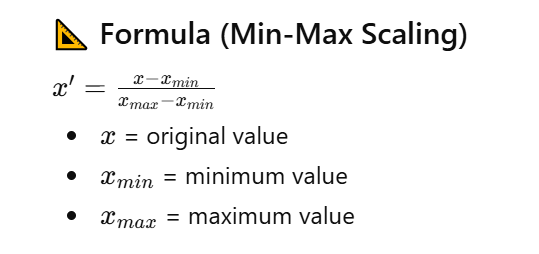

In [2]:
# Normalization ka matlab:

# “Data ko squeeze karna ek fixed range me”

In [3]:
# Why use Normalization?
#   1. Distance-based models ke liye best
#             KNN
#             K-means

#  Distance calculation correct hoti hai

# 2. Neural Networks me useful
#    Input values controlled range me hote hain

# 3. Jab data bounded chahiye
#     Image pixel values (0–255 → 0–1)

In [4]:
# Kab problem hoti hai?
#  Outliers hone par

#   Example:

# max = 1,000,000 (outlier)

#   Baaki sab values squeeze ho jayengi

| Feature  | Normalization | Standardization |
| -------- | ------------- | --------------- |
| Range    | 0–1           | No fixed range  |
| Mean     | change hota   | 0               |
| Outliers | sensitive ❌   | better handle   |
| Use case | bounded data  | Gaussian data   |


In [5]:
# Normalization = data ko 0–1 range me lana 
#     Best for:

# KNN
# Neural Networks
# Image data

#   Avoid:

#      Jab outliers ho

In [6]:
import pandas as pd

data = pd.DataFrame({
    "Age": [22,25,30,35,40,28,32,45,50,38],
    "Salary": [25000,30000,50000,60000,80000,45000,52000,90000,120000,70000],
    "Experience": [1,2,5,7,10,4,6,12,15,9],
    "Distance": [5,10,3,8,2,6,4,1,7,9],
    "Hours_per_week": [40,45,50,55,60,48,52,65,70,58],
    "Projects": [1,2,3,4,5,2,3,6,7,5],
    "Performance_score": [60,65,70,75,80,68,72,85,90,78]
})



In [7]:
data

,Age,Salary,Experience,Distance,Hours_per_week,Projects,Performance_score
0,22,25000,1,5,40,1,60
1,25,30000,2,10,45,2,65
2,30,50000,5,3,50,3,70
3,35,60000,7,8,55,4,75
4,40,80000,10,2,60,5,80
5,28,45000,4,6,48,2,68
6,32,52000,6,4,52,3,72
7,45,90000,12,1,65,6,85
8,50,120000,15,7,70,7,90
9,38,70000,9,9,58,5,78


In [8]:
# Salary dominate karega
# Distance, Projects ignore ho sakte hain

# Before Normalization (Graph)

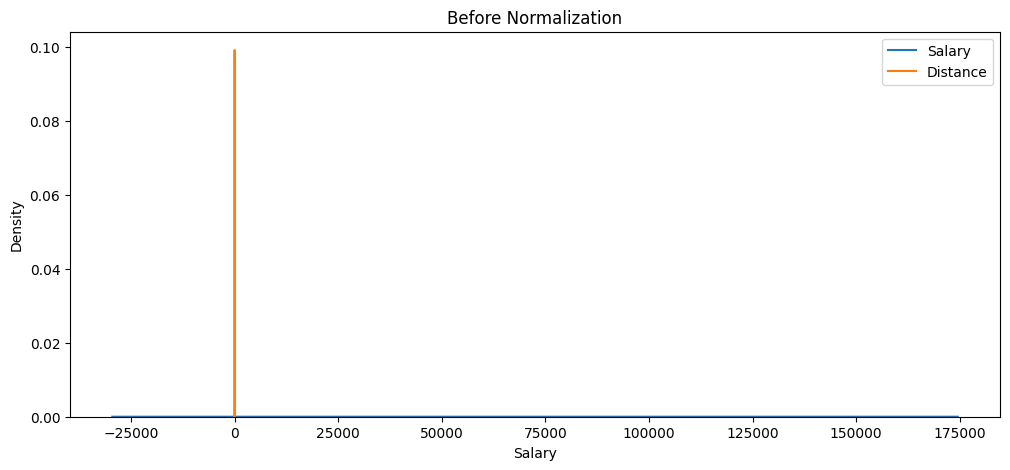

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.kdeplot(data["Salary"], label="Salary")
sns.kdeplot(data["Distance"], label="Distance")

plt.title("Before Normalization")
plt.legend()
plt.show()

# Step 4: Normalization apply (MinMaxScaler)

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

df_norm = pd.DataFrame(scaled_data, columns=data.columns)

df_norm

,Age,Salary,Experience,Distance,Hours_per_week,Projects,Performance_score
0,0.000000,0.000000,0.000000,0.444444,0.000000,0.000000,0.000000
1,0.107143,0.052632,0.071429,1.000000,0.166667,0.166667,0.166667
2,0.285714,0.263158,0.285714,0.222222,0.333333,0.333333,0.333333
3,0.464286,0.368421,0.428571,0.777778,0.500000,0.500000,0.500000
4,0.642857,0.578947,0.642857,0.111111,0.666667,0.666667,0.666667
5,0.214286,0.210526,0.214286,0.555556,0.266667,0.166667,0.266667
6,0.357143,0.284211,0.357143,0.333333,0.400000,0.333333,0.400000
7,0.821429,0.684211,0.785714,0.000000,0.833333,0.833333,0.833333
8,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000
9,0.571429,0.473684,0.571429,0.888889,0.600000,0.666667,0.600000


# After Normalization Graph

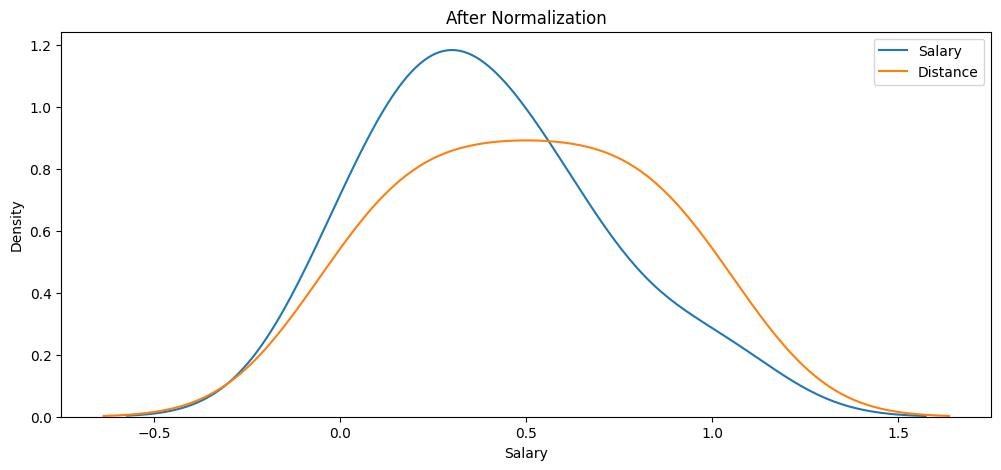

In [11]:
plt.figure(figsize=(12,5))

sns.kdeplot(df_norm["Salary"], label="Salary")
sns.kdeplot(df_norm["Distance"], label="Distance")

plt.title("After Normalization")
plt.legend()
plt.show()

In [12]:
# Agar dataset me outliers ho:

# Normalization kharab ho sakta hai

In [13]:
# Normalization data ko 0–1 range me compress karta hai

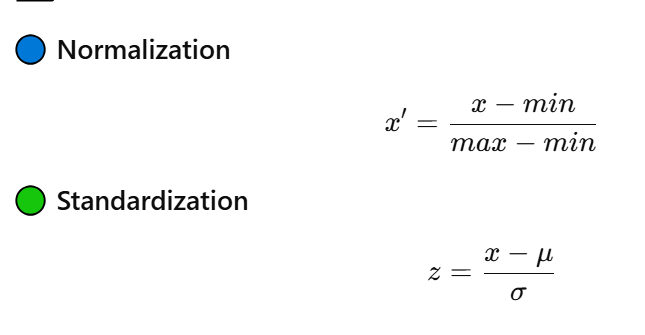

| Feature      | Normalization  | Standardization  |
| ------------ | -------------- | ---------------- |
| Range        | 0–1            | No fixed range   |
| Mean         | change hota    | 0                |
| Std          | change hota    | 1                |
| Outliers     | sensitive ❌    | better ✔️        |
| Distribution | preserve karta | reshape karta    |
| Best for     | KNN, NN        | Linear, Logistic |


In [15]:
#   Normalization scales data between 0 and 1, while standardization transforms data to have mean 0 and unit variance. 
# Standardization is less sensitive to outliers and preferred for many ML algorithms.

In [16]:
# Normalization = range fix
# Standardization = distribution fix

In [17]:
import numpy as np
import pandas as pd

np.random.seed(0)

# features
age = np.random.randint(20, 60, 100)
salary = np.random.randint(20000, 120000, 100)

# target (simple rule)
purchased = (salary > 60000).astype(int)

df = pd.DataFrame({
    "Age": age,
    "Salary": salary,
    "Purchased": purchased
})

In [18]:
df

,Age,Salary,Purchased
0,20,44777,0
1,23,33824,0
2,23,22418,0
3,59,32843,0
4,29,98778,1
...,...,...,...
95,23,75270,1
96,54,32579,0
97,33,91382,1
98,59,67805,1


In [19]:
from sklearn.model_selection import train_test_split

X = df[["Age", "Salary"]]
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Scaling (Normalization vs Standardization)

In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalization
minmax = MinMaxScaler()
X_train_norm = minmax.fit_transform(X_train)
X_test_norm = minmax.transform(X_test)

# Standardization
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

# Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression

# Normalized model
model_norm = LogisticRegression()
model_norm.fit(X_train_norm, y_train)

# Standardized model
model_std = LogisticRegression()
model_std.fit(X_train_std, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
from sklearn.metrics import accuracy_score

y_pred_norm = model_norm.predict(X_test_norm)
y_pred_std = model_std.predict(X_test_std)

print("Normalization:", accuracy_score(y_test, y_pred_norm))
print("Standardization:", accuracy_score(y_test, y_pred_std))

Normalization: 1.0
Standardization: 1.0


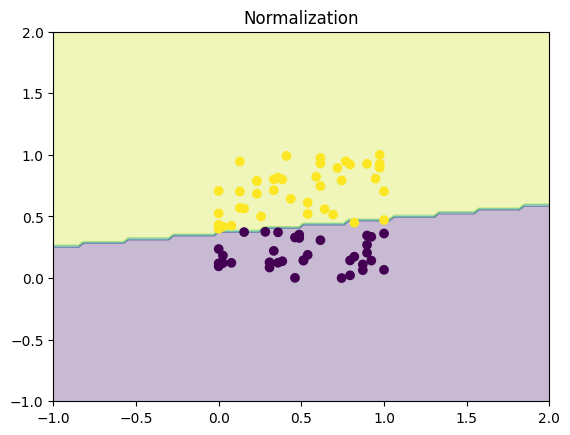

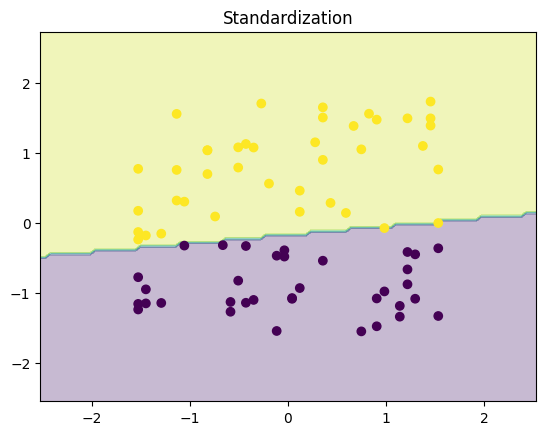

In [23]:
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, model, title):
    X = np.array(X)
    y = np.array(y)

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(title)
    plt.show()


# Plot
plot_decision_boundary(X_train_norm, y_train, model_norm, "Normalization")
plot_decision_boundary(X_train_std, y_train, model_std, "Standardization")

| Model               | Best Scaling      |
| ------------------- | ----------------- |
| Logistic Regression | ✅ Standardization |
| KNN                 | ✅ Normalization   |
| Neural Networks     | ✅ Normalization   |
